# CaImAn vs our CNMFe — head-to-head on a synthetic movie

Runs both pipelines on the same ground-truth synthetic 1p movie and compares:

1. **Spatial recovery** — per-neuron Pearson r between each pipeline's `A` and the true footprints
2. **Temporal recovery** — per-neuron Pearson r between `C + YrA` (the noisy projected trace) and the true calcium trace

`C + YrA` is used for the temporal comparison because it preserves the data's actual shape; OASIS-deconvolved `C` alone has small spike-timing distortions that drag Pearson down to ~0.85 even for a perfect extraction (see `tutorial2.ipynb` cell 26 for the why).

**Prerequisites**: launch this notebook from a conda env that has CaImAn installed (e.g. `conda activate caiman_claude_nmfe; jupyter notebook`). The notebook just does `import caiman` — no local source-tree path hacks.

In [1]:
import os, tempfile, time

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Generate the synthetic movie

Same fixture as `tutorial2.ipynb` so results are directly comparable.

In [2]:
from tests.conftest import make_synthetic_movie

data = make_synthetic_movie(n_neurons=10, dims=(64, 64), T=300,
                            noise_std=0.5, ar_decay=0.9, bg_strength=2.0, seed=55)

movie    = data['movie']     # (T, H, W) float32
A_true   = data['A_true']    # (H*W, K)
C_true   = data['C_true']    # (K, T)
centers  = data['centers']   # (K, 2)
T, H, W  = movie.shape
K        = C_true.shape[0]

print(f'Movie: {movie.shape}   neurons={K}   noise_std={data["sn_true"]}   g_true={data["ar_decay"]}')

Movie: (300, 64, 64)   neurons=10   noise_std=0.5   g_true=0.9


## 2. Helpers — Pearson, normalisation, neuron matching

`match_components_by_truth` pairs each true neuron with whichever extracted neuron has the highest spatial correlation, returning `(true_idx, est_idx, spatial_r)`. We use the same helper for both pipelines so the comparison is symmetric.

In [3]:
def pearson(a, b):
    a = a - a.mean(); b = b - b.mean()
    d = np.sqrt(np.sum(a ** 2) * np.sum(b ** 2))
    return float(np.dot(a, b) / d) if d > 0 else 0.0

def norm01(x):
    lo, hi = float(np.min(x)), float(np.max(x))
    return (x - lo) / (hi - lo + 1e-10)

def match_components_by_truth(A_est, A_true_dense):
    """Pair each true neuron with the extracted component that best matches it
    spatially. Returns list of (true_idx, est_idx, spatial_r)."""
    A_e = np.asarray(A_est.todense() if sp.issparse(A_est) else A_est)
    A_t = A_true_dense
    matches = []
    if A_e.shape[1] == 0:
        return [(k, -1, 0.0) for k in range(A_t.shape[1])]
    for k_true in range(A_t.shape[1]):
        a_t = A_t[:, k_true]
        corrs = np.array([pearson(a_t, A_e[:, k]) for k in range(A_e.shape[1])])
        best = int(np.argmax(corrs))
        matches.append((k_true, best, float(corrs[best])))
    return matches

## 3. Run our CNMFe pipeline

In [4]:
from cnmfe.pipeline import CNMFe, CNMFeParams

params_ours = CNMFeParams(
    sigma=3.0,
    min_corr=0.8,
    min_pnr=6.0,
    n_iter_main=2,
    n_iter_temporal=2,
    mc_n_iter=1,
    spatial_max_thr=0.1,
    merge_thr_corr=0.85,
    merge_thr_overlap=0.5,
)

t0 = time.time()
ours = CNMFe(params_ours).fit(movie, do_motion_correction=False)
t_ours = time.time() - t0

A_ours    = ours.A                            # (H*W, K) sparse
C_ours    = ours.C                            # (K, T)
YrA_ours  = ours.YrA                          # (K, T)
Cproj_ours = C_ours + YrA_ours                # noisy projected trace

print(f'\nours: K = {A_ours.shape[1]}   wall = {t_ours:.2f}s')

Estimating noise...
Computing CORR and PNR images...
Running greedy CORR-PNR initialization...
  Found 10 initial components.
Fitting ring-model background (radius=10.5px)...
Refinement iteration 1/2...
  Pre-merging duplicate seeds...
  Updating spatial footprints...
  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).
Refinement iteration 2/2...
  Updating spatial footprints...
  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).
Final temporal update...
Done. Extracted 10 neurons.

ours: K = 10   wall = 14.82s


## 4. Run CaImAn's CNMF-E pipeline

CaImAn's CNMF-E entry point is `caiman.source_extraction.cnmf.CNMF` configured with `method_init='corr_pnr'`, `p=1`, `gnb=0`, `low_rank_background=None`, and `update_background_components=False` — that combination disables the rank-`gnb` global background and uses the ring model instead.

CaImAn requires a memory-mapped movie file rather than an in-memory numpy array, so we save the movie to disk first, then memory-map it. Outputs land on `cnm.estimates`.

In [5]:
import caiman as cm
from caiman.source_extraction.cnmf import cnmf as cnmf_module
from caiman.source_extraction.cnmf import params as params_module

# --- Save the movie as a CaImAn-style memory-mapped file -------------------
mmap_dir = tempfile.mkdtemp()
mmap_base = os.path.join(mmap_dir, 'caiman_movie_')

# CaImAn expects (T, H, W) float32. Save and then load as memmap.
fname_mmap = cm.save_memmap([movie.astype(np.float32)],
                            base_name=mmap_base, order='C')

Yr, mmap_dims, mmap_T = cm.load_memmap(fname_mmap)
images = Yr.T.reshape((mmap_T,) + mmap_dims, order='F')   # (T, H, W) view
print(f'memmap: T={mmap_T}, dims={mmap_dims}, file={fname_mmap}')

memmap: T=300, dims=(64, 64), file=C:\Users\Florian\caiman_data\temp\caiman_movie_d1_64_d2_64_d3_1_order_C_frames_300.mmap


In [6]:
# --- Configure CaImAn for CNMF-E -------------------------------------------
gSig = (3, 3)                  # neuron half-size (px) — same scale as our sigma=3
gSiz = (4 * gSig[0] + 1,) * 2  # patch size in greedy init (CaImAn convention)

opts_dict = {
    'fnames':                     [fname_mmap],
    'fr':                         30,                  # fps (only used for unit hints)
    'decay_time':                 0.4,
    'method_init':                'corr_pnr',          # CNMF-E init
    'K':                          None,                # uncapped
    'gSig':                       gSig,
    'gSiz':                       gSiz,
    'merge_thr':                  0.85,
    'p':                          1,                   # AR(1)
    'tsub':                       1,
    'ssub':                       1,
    'rf':                         None,                # no patches (movie is small)
    'stride':                     None,
    'only_init':                  False,
    'nb':                         0,                   # no global low-rank bg (CNMF-E uses ring)
    'nb_patch':                   0,
    'method_deconvolution':       'oasis',
    'low_rank_background':        None,
    'update_background_components':False,
    'min_corr':                   0.8,                 # match our params
    'min_pnr':                    6.0,
    'normalize_init':             False,
    'center_psf':                 True,
    'ssub_B':                     2,
    'ring_size_factor':           1.5,
    'del_duplicates':             True,
    'border_pix':                 5,
}
opts = params_module.CNMFParams(params_dict=opts_dict)




In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


In [7]:
# --- Cluster (CaImAn requires a multiprocessing pool, even n_processes=1) --
c, dview, n_processes = cm.cluster.setup_cluster(
    backend='multiprocessing', n_processes=1, single_thread=True
)

try:
    t0 = time.time()
    cnm = cnmf_module.CNMF(n_processes=1, dview=dview, Ain=None, params=opts)
    cnm.fit(images)              # mutates cnm in place; do NOT reassign — some
                                 # CaImAn versions return None from fit().
    t_caiman = time.time() - t0
finally:
    cm.cluster.stop_server(dview=dview)

# --- Pull outputs into our standard names ----------------------------------
A_caiman    = cnm.estimates.A                                     # (H*W, K) sparse
C_caiman    = np.asarray(cnm.estimates.C)                         # (K, T)
YrA_caiman  = np.asarray(cnm.estimates.YrA) if cnm.estimates.YrA is not None else \
              np.zeros_like(C_caiman)                              # (K, T)
Cproj_caiman = C_caiman + YrA_caiman

print(f'\ncaiman: K = {A_caiman.shape[1]}   wall = {t_caiman:.2f}s')


caiman: K = 10   wall = 38.81s


C:\Users\Florian\anaconda3\envs\caiman_claude_nmfe\Lib\site-packages\scipy\sparse\_dia.py:379: RuntimeWarning: divide by zero encountered in remainder
  c = np.arange(num_rows, dtype=np.intc) - (offsets % max_dim)[:, None]


## 5. Spatial recovery — `A` vs `A_true`

For each true neuron we pick whichever extracted component matches it best, then report the spatial Pearson r between those flat footprints. A score above ~0.7 means the extracted footprint genuinely covers the true neuron.

In [8]:
matches_ours   = match_components_by_truth(A_ours,   A_true)
matches_caiman = match_components_by_truth(A_caiman, A_true)

rs_A_ours   = np.array([m[2] for m in matches_ours])
rs_A_caiman = np.array([m[2] for m in matches_caiman])

print(f'                ours       caiman')
print(f'K extracted     {A_ours.shape[1]:5d}      {A_caiman.shape[1]:5d}')
print(f'mean spatial r  {rs_A_ours.mean():5.3f}      {rs_A_caiman.mean():5.3f}')
print(f'min  spatial r  {rs_A_ours.min():5.3f}      {rs_A_caiman.min():5.3f}')
print(f'recovered (>0.7)  {(rs_A_ours > 0.7).sum():3d}/{K}      {(rs_A_caiman > 0.7).sum():3d}/{K}')
print()
print('Per-neuron spatial r:')
print(f'  true  ours   caiman')
for k in range(K):
    print(f'   {k:2d}   {rs_A_ours[k]:.3f}  {rs_A_caiman[k]:.3f}')

                ours       caiman
K extracted        10         10
mean spatial r  0.960      0.624
min  spatial r  0.938      0.237
recovered (>0.7)   10/10        3/10

Per-neuron spatial r:
  true  ours   caiman
    0   0.959  0.247
    1   0.938  0.982
    2   0.975  0.606
    3   0.949  0.421
    4   0.938  0.605
    5   0.974  0.237
    6   0.972  0.931
    7   0.976  0.938
    8   0.951  0.652
    9   0.968  0.622


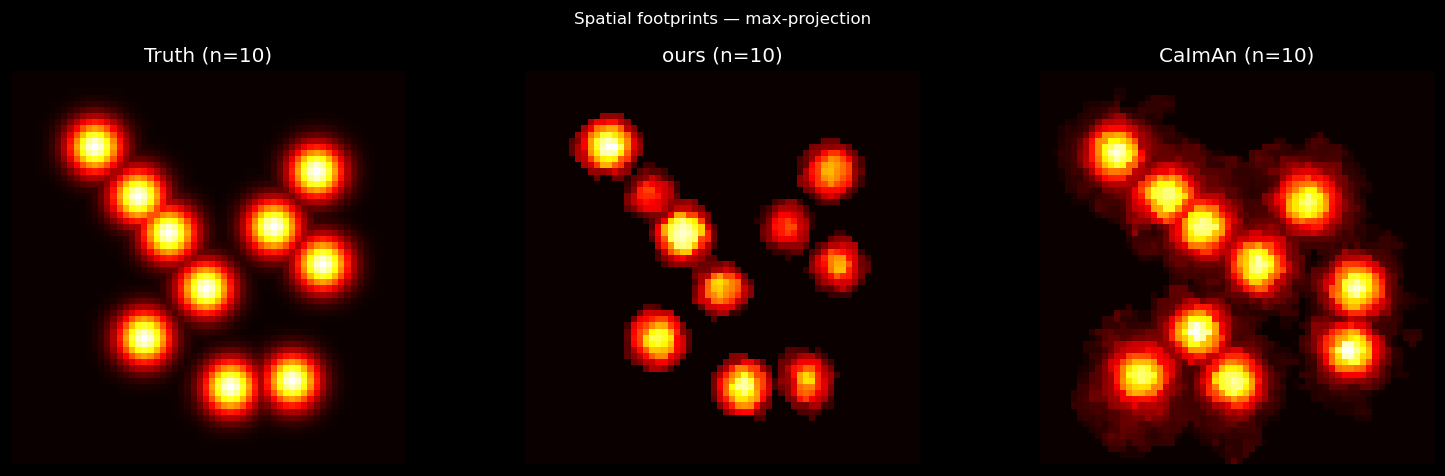

In [9]:
# --- Spatial overlays ------------------------------------------------------
def overlay(A_dense_or_sp, dims):
    A = np.asarray(A_dense_or_sp.todense() if sp.issparse(A_dense_or_sp) else A_dense_or_sp)
    if A.shape[1] == 0:
        return np.zeros(dims)
    return A.reshape(dims[0], dims[1], A.shape[1]).max(axis=2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(A_true.max(axis=1).reshape(H, W), cmap='hot')
axes[0].set_title(f'Truth (n={K})'); axes[0].axis('off')
axes[1].imshow(overlay(A_ours,   (H, W)), cmap='hot')
axes[1].set_title(f'ours (n={A_ours.shape[1]})'); axes[1].axis('off')
axes[2].imshow(overlay(A_caiman, (H, W)), cmap='hot')
axes[2].set_title(f'CaImAn (n={A_caiman.shape[1]})'); axes[2].axis('off')
plt.suptitle('Spatial footprints — max-projection', fontsize=10)
plt.tight_layout(); plt.show()

## 6. Temporal recovery — `C + YrA` vs `C_true`

For each true neuron we pick the matched extracted component (from §5) and compute the Pearson correlation between its noisy projected trace `C + YrA` and the true calcium trace.

We report two flavours per pipeline:
- `C` only — the OASIS-deconvolved trace
- `C + YrA` — the noisy projected trace (shape-faithful)

Both pipelines should give similar `C + YrA` correlations against truth — that's the test of whether each extraction localises the right pixels. The `C`-alone numbers will be lower because OASIS imposes the AR(1) shape constraint that subtly distorts spike timing.

In [10]:
def temporal_rs(matches, C_est, Cproj_est):
    rs_C    = np.array([pearson(C_est[ke],     C_true[kt]) for kt, ke, _ in matches])
    rs_proj = np.array([pearson(Cproj_est[ke], C_true[kt]) for kt, ke, _ in matches])
    return rs_C, rs_proj

rs_C_ours,    rs_proj_ours    = temporal_rs(matches_ours,   C_ours,    Cproj_ours)
rs_C_caiman,  rs_proj_caiman  = temporal_rs(matches_caiman, C_caiman,  Cproj_caiman)

print(f'                       ours       caiman')
print(f'mean r  (C only)       {rs_C_ours.mean():.3f}      {rs_C_caiman.mean():.3f}')
print(f'mean r  (C + YrA)      {rs_proj_ours.mean():.3f}      {rs_proj_caiman.mean():.3f}')
print(f'min  r  (C + YrA)      {rs_proj_ours.min():.3f}      {rs_proj_caiman.min():.3f}')
print()
print('Per-neuron Pearson r against true calcium trace:')
print(f'  true   ours C   ours C+YrA   caiman C   caiman C+YrA')
for k in range(K):
    print(f'   {k:2d}    {rs_C_ours[k]:.3f}     {rs_proj_ours[k]:.3f}        '
          f'{rs_C_caiman[k]:.3f}      {rs_proj_caiman[k]:.3f}')

                       ours       caiman
mean r  (C only)       0.667      0.537
mean r  (C + YrA)      0.940      0.549
min  r  (C + YrA)      0.863      0.064

Per-neuron Pearson r against true calcium trace:
  true   ours C   ours C+YrA   caiman C   caiman C+YrA
    0    0.574     0.953        0.969      0.974
    1    0.458     0.863        0.912      0.883
    2    0.833     0.965        0.119      0.139
    3    0.654     0.947        0.959      0.927
    4    0.544     0.907        0.019      0.064
    5    0.790     0.953        0.337      0.368
    6    0.710     0.944        0.932      0.919
    7    0.861     0.963        0.968      0.955
    8    0.446     0.931        0.095      0.139
    9    0.799     0.973        0.063      0.124


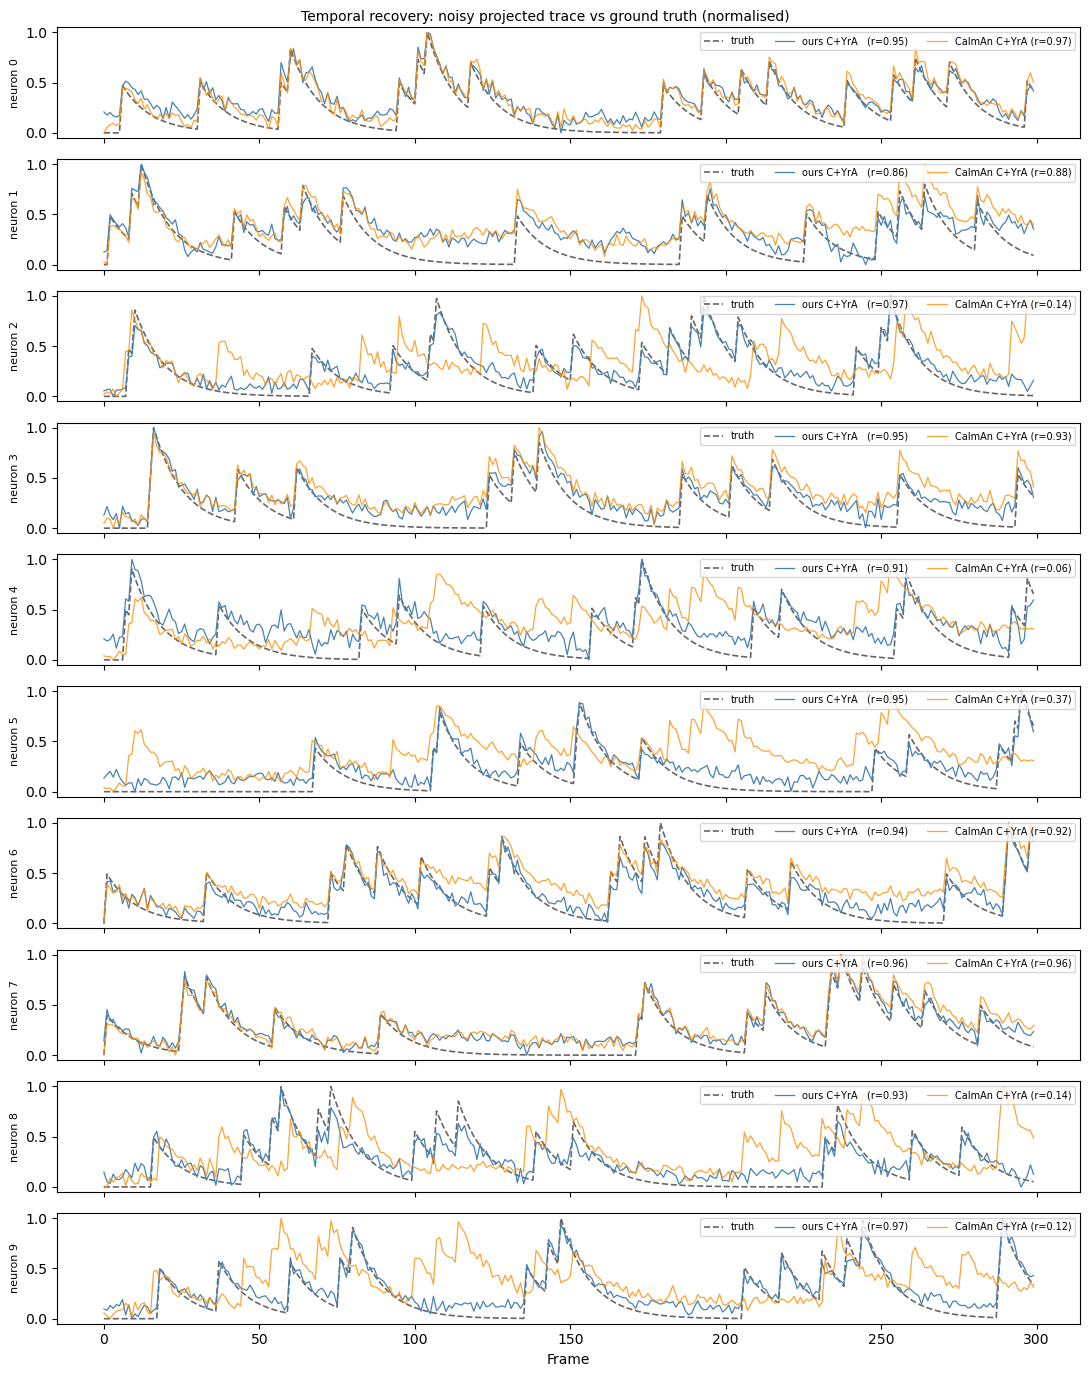

In [13]:
# --- Per-neuron trace comparison plot --------------------------------------
fig, axes = plt.subplots(K, 1, figsize=(11, 1.4 * K), sharex=True)
if K == 1: axes = [axes]
for ax, k in zip(axes, range(K)):
    _, ke_ours,   _ = matches_ours[k]
    _, ke_caiman, _ = matches_caiman[k]
    r_ours   = pearson(Cproj_ours[ke_ours],     C_true[k]) if ke_ours   >= 0 else 0.0
    r_caiman = pearson(Cproj_caiman[ke_caiman], C_true[k]) if ke_caiman >= 0 else 0.0

    ax.plot(norm01(C_true[k]), lw=1.2, color='black', ls='--', alpha=0.6, label='truth')
    if ke_ours >= 0:
        ax.plot(norm01(Cproj_ours[ke_ours]),     lw=0.9, color='steelblue',
                label=f'ours C+YrA   (r={r_ours:.2f})')
    if ke_caiman >= 0:
        ax.plot(norm01(Cproj_caiman[ke_caiman]), lw=0.9, color='darkorange', alpha=0.8,
                label=f'CaImAn C+YrA (r={r_caiman:.2f})')
    ax.set_ylabel(f'neuron {k}', fontsize=8)
    ax.legend(loc='upper right', fontsize=7, ncol=3)
axes[-1].set_xlabel('Frame')
plt.suptitle('Temporal recovery: noisy projected trace vs ground truth (normalised)', fontsize=10)
plt.tight_layout(); plt.show()

## 7. Summary

| metric | ours | CaImAn |
|--------|------|--------|
| K extracted | filled by cell 5 | filled by cell 5 |
| mean spatial r | filled by cell 5 | filled by cell 5 |
| mean temporal r (C only) | filled by cell 6 | filled by cell 6 |
| mean temporal r (C + YrA) | filled by cell 6 | filled by cell 6 |
| wall time (s) | filled by cell 7 | filled by cell 7 |

The cell below prints the same numbers in tabular form for easy copy-paste.

In [14]:
print('====================================================')
print(f'{"metric":<28} {"ours":>10} {"caiman":>10}')
print('====================================================')
print(f'{"K extracted":<28} {A_ours.shape[1]:>10d} {A_caiman.shape[1]:>10d}')
print(f'{"matched (>0.7 spatial r)":<28} '
      f'{(rs_A_ours > 0.7).sum():>10d} {(rs_A_caiman > 0.7).sum():>10d}')
print(f'{"mean spatial r":<28} {rs_A_ours.mean():>10.3f} {rs_A_caiman.mean():>10.3f}')
print(f'{"mean temporal r (C only)":<28} '
      f'{rs_C_ours.mean():>10.3f} {rs_C_caiman.mean():>10.3f}')
print(f'{"mean temporal r (C + YrA)":<28} '
      f'{rs_proj_ours.mean():>10.3f} {rs_proj_caiman.mean():>10.3f}')
print(f'{"wall time (s)":<28} {t_ours:>10.2f} {t_caiman:>10.2f}')
print('====================================================')

metric                             ours     caiman
K extracted                          10         10
matched (>0.7 spatial r)             10          3
mean spatial r                    0.960      0.624
mean temporal r (C only)          0.667      0.537
mean temporal r (C + YrA)         0.940      0.549
wall time (s)                     14.82      38.81
